<a href="https://colab.research.google.com/github/zeynepuguz/DeepLearningProject/blob/1220505038/DeepLearningProject_Group_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import splitfolders

# input_folder = "/content/drive/MyDrive/Colab Notebooks/Corn Disease/data"
# output_folder = "/content/drive/MyDrive/Colab Notebooks/Corn Disease/split"

# splitfolders.ratio(
#     input_folder,
#     output=output_folder,
#     seed=42,
#     ratio=(.7, .1, .2)
# )


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)


In [ ]:
base_dir = "/content/drive/MyDrive/Colab Notebooks/Corn Disease/split"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

print("Train:", train_dir)
print("Val:  ", val_dir)
print("Test: ", test_dir)


Train: /content/drive/MyDrive/Colab Notebooks/Corn Disease/split/train
Val:   /content/drive/MyDrive/Colab Notebooks/Corn Disease/split/val
Test:  /content/drive/MyDrive/Colab Notebooks/Corn Disease/split/test


In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_gen.num_classes
print("Sınıf sayısı:", num_classes)
print("Sınıf isimleri:", train_gen.class_indices)


Found 2937 images belonging to 4 classes.
Found 417 images belonging to 4 classes.
Found 843 images belonging to 4 classes.
Sınıf sayısı: 4
Sınıf isimleri: {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}


In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),

    ModelCheckpoint(
        filepath="cnn_best.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]


In [ ]:
epochs = 20

history_cnn = cnn_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=callbacks_cnn
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5117 - loss: 1.3074
Epoch 1: val_accuracy improved from -inf to 0.77218, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 904s 10s/step - accuracy: 0.5127 - loss: 1.3038 - val_accuracy: 0.7722 - val_loss: 0.5969 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.7767 - loss: 0.5967
Epoch 2: val_accuracy improved from 0.77218 to 0.81535, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 541ms/step - accuracy: 0.7768 - loss: 0.5964 - val_accuracy: 0.8153 - val_loss: 0.4367 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.8107 - loss: 0.4779
Epoch 3: val_accuracy did not improve from 0.81535
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 517ms/step - accuracy: 0.8107 - loss: 0.4777 - val_accuracy: 0.7674 - val_loss: 0.5858 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.8278 - loss: 0.4343
Epoch 4: val_accuracy improved from 0.81535 to 0.84892, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 523ms/step - accuracy: 0.8277 - loss: 0.4343 - val_accuracy: 0.8489 - val_loss: 0.3983 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8265 - loss: 0.4634
Epoch 5: val_accuracy did not improve from 0.84892
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 526ms/step - accuracy: 0.8266 - loss: 0.4631 - val_accuracy: 0.8417 - val_loss: 0.3457 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8341 - loss: 0.3958
Epoch 6: val_accuracy improved from 0.84892 to 0.85132, saving model to cnn_best.h5


...

92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 523ms/step - accuracy: 0.8327 - loss: 0.3849 - val_accuracy: 0.8561 - val_loss: 0.3315 - learning_rate: 0.0010
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8368 - loss: 0.3706
Epoch 9: val_accuracy did not improve from 0.85612
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 509ms/step - accuracy: 0.8369 - loss: 0.3706 - val_accuracy: 0.8513 - val_loss: 0.3545 - learning_rate: 0.0010
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.8345 - loss: 0.3856
Epoch 10: val_accuracy improved from 0.85612 to 0.87770, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 529ms/step - accuracy: 0.8345 - loss: 0.3855 - val_accuracy: 0.8777 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.8467 - loss: 0.3684
Epoch 11: val_accuracy improved from 0.87770 to 0.88729, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 529ms/step - accuracy: 0.8467 - loss: 0.3682 - val_accuracy: 0.8873 - val_loss: 0.2833 - learning_rate: 0.0010
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8502 - loss: 0.3589
Epoch 12: val_accuracy did not improve from 0.88729
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 508ms/step - accuracy: 0.8502 - loss: 0.3588 - val_accuracy: 0.8417 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8493 - loss: 0.3452
Epoch 13: val_accuracy improved from 0.88729 to 0.89688, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 526ms/step - accuracy: 0.8494 - loss: 0.3452 - val_accuracy: 0.8969 - val_loss: 0.2827 - learning_rate: 0.0010
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.8587 - loss: 0.3363
Epoch 14: val_accuracy improved from 0.89688 to 0.90408, saving model to cnn_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 520ms/step - accuracy: 0.8587 - loss: 0.3362 - val_accuracy: 0.9041 - val_loss: 0.2945 - learning_rate: 0.0010
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8504 - loss: 0.3320
Epoch 15: val_accuracy did not improve from 0.90408
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 514ms/step - accuracy: 0.8504 - loss: 0.3319 - val_accuracy: 0.8825 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.8502 - loss: 0.3380
Epoch 16: val_accuracy did not improve from 0.90408

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 519ms/step - accuracy: 0.8502 - loss: 0.3379 - val_accuracy: 0.8705 - val_loss: 0.3009 - learning_rate: 0.0010
Epoch 17/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.8684 - loss: 0.3138
Epoch 17: val_accuracy did not improve from 0.90408
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 513ms/step - accuracy: 0.8684 - loss: 0.3138 - v

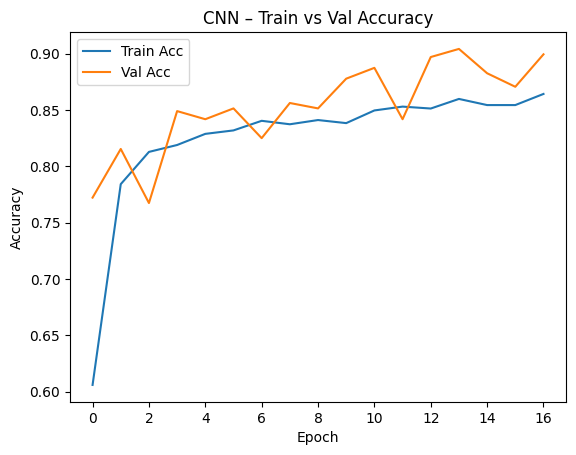

In [ ]:
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("CNN – Train vs Val Accuracy")
plt.show()

In [ ]:
cnn_y_pred = cnn_model.predict(test_gen)
cnn_y_pred_classes = np.argmax(cnn_y_pred, axis=1)

cnn_y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

print("İlk 10 tahmin:", cnn_y_pred_classes[:10])
print("İlk 10 gerçek:", cnn_y_true[:10])

27/27 ━━━━━━━━━━━━━━━━━━━━ 269s 10s/step
İlk 10 tahmin: [2 0 2 0 0 0 0 0 0 0]
İlk 10 gerçek: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        cnn_y_true,
        cnn_y_pred_classes,
        target_names=class_labels,
        digits=4
    )
)


                precision    recall  f1-score   support

        Blight     0.7713    0.8578    0.8122       232
   Common_Rust     0.9750    0.8931    0.9323       262
Gray_Leaf_Spot     0.7087    0.6293    0.6667       116
       Healthy     0.9628    1.0000    0.9811       233

      accuracy                         0.8766       843
     macro avg     0.8545    0.8450    0.8481       843
  weighted avg     0.8789    0.8766    0.8762       843



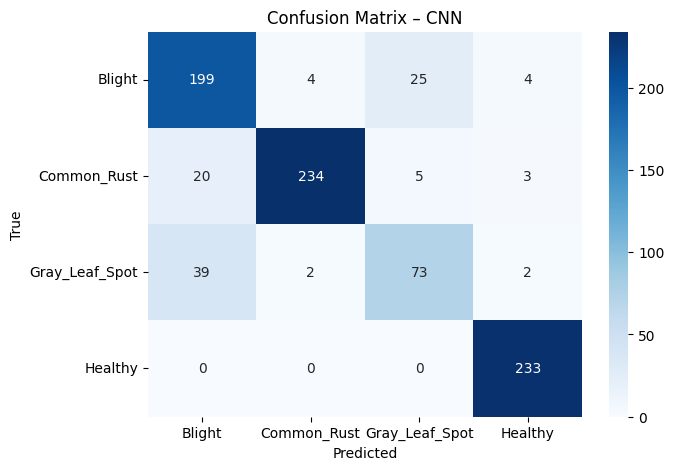

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred_classes)

plt.figure(figsize=(7,5))
sns.heatmap(cnn_cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – CNN")
plt.show()


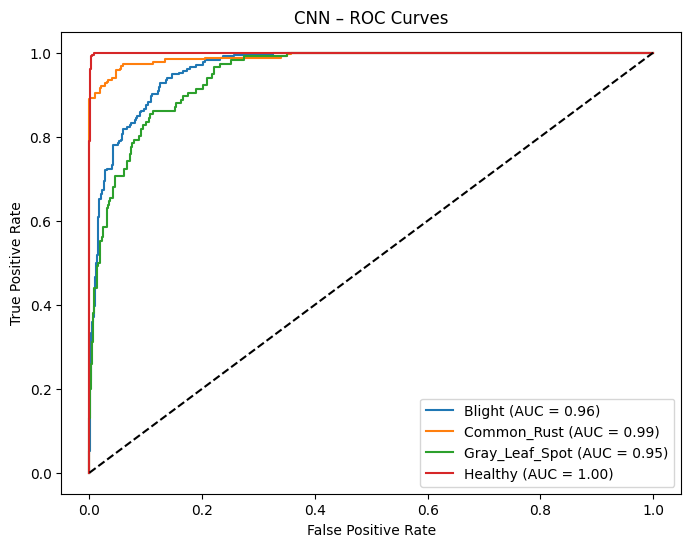

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

cnn_y_true_bin = label_binarize(cnn_y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(cnn_y_true_bin[:, i], cnn_y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN – ROC Curves")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

mobilenet_base.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = layers.Input(shape=(img_size[0], img_size[1], 3))
x = mobilenet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

mobilenet_model = models.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks_mobilenet = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='mobilenetv2_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_mobilenet
)


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.6779 - loss: 0.8256
Epoch 1: val_accuracy improved from -inf to 0.87050, saving model to mobilenetv2_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 88s 779ms/step - accuracy: 0.6791 - loss: 0.8227 - val_accuracy: 0.8705 - val_loss: 0.3108 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.8817 - loss: 0.3195
Epoch 2: val_accuracy improved from 0.87050 to 0.89688, saving model to mobilenetv2_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 514ms/step - accuracy: 0.8816 - loss: 0.3194 - val_accuracy: 0.8969 - val_loss: 0.2490 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8931 - loss: 0.2730
Epoch 3: val_accuracy improved from 0.89688 to 0.91367, saving model to mobilenetv2_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 510ms/step - accuracy: 0.8931 - loss: 0.2728 - val_accuracy: 0.9137 - val_loss: 0.2286 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9116 - loss: 0.2500
Epoch 4: val_accuracy improved from 0.91367 to 0.91607, saving model to mobilenetv2_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 513ms/step - accuracy: 0.9115 - loss: 0.2501 - val_accuracy: 0.9161 - val_loss: 0.2353 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9167 - loss: 0.2263
Epoch 5: val_accuracy did not improve from 0.91607
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 504ms/step - accuracy: 0.9166 - loss: 0.2265 - val_accuracy: 0.9017 - val_loss: 0.2041 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9138 - loss: 0.2322
Epoch 6: val_accuracy improved from 0.91607 to 0.92326, saving model to mobilenetv2_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 530ms/step - accuracy: 0.9138 - loss: 0.2322 - val_accuracy: 0.9233 - val_loss: 0.1903 - learning_rate: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9166 - loss: 0.2108
Epoch 7: val_accuracy did not improve from 0.92326
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 504ms/step - accuracy: 0.9165 - loss: 0.2109 - val_accuracy: 0.9233 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9243 - loss: 0.1927
Epoch 8: val_accuracy did not improve from 0.92326

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 518ms/step - accuracy: 0.9242 - loss: 0.1929 - val_accuracy: 0.9137 - val_loss: 0.1894 - learning_rate: 0.0010
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9177 - loss: 0.2002
Epoch 9: val_accuracy did not improve from 0.92326
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 506ms/step - accuracy: 0.9177 - loss: 0.2003 - val_accu

In [ ]:
mobilenet_y_pred = mobilenet_model.predict(test_gen)
mobilenet_y_pred_classes = np.argmax(mobilenet_y_pred, axis=1)

mobilenet_y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("İlk 10 tahmin:", mobilenet_y_pred_classes[:10])
print("İlk 10 gerçek:", mobilenet_y_true[:10])


27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 586ms/step
İlk 10 tahmin: [0 0 0 0 0 0 0 0 0 0]
İlk 10 gerçek: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print("MobileNetV2 - Classification Report:")
print(classification_report(
    mobilenet_y_true,
    mobilenet_y_pred_classes,
    target_names=class_labels,
    digits=4
))


MobileNetV2 - Classification Report:
                precision    recall  f1-score   support

        Blight     0.8670    0.8707    0.8688       232
   Common_Rust     0.9517    0.9771    0.9642       262
Gray_Leaf_Spot     0.7944    0.7328    0.7623       116
       Healthy     0.9957    1.0000    0.9979       233

      accuracy                         0.9205       843
     macro avg     0.9022    0.8951    0.8983       843
  weighted avg     0.9189    0.9205    0.9195       843



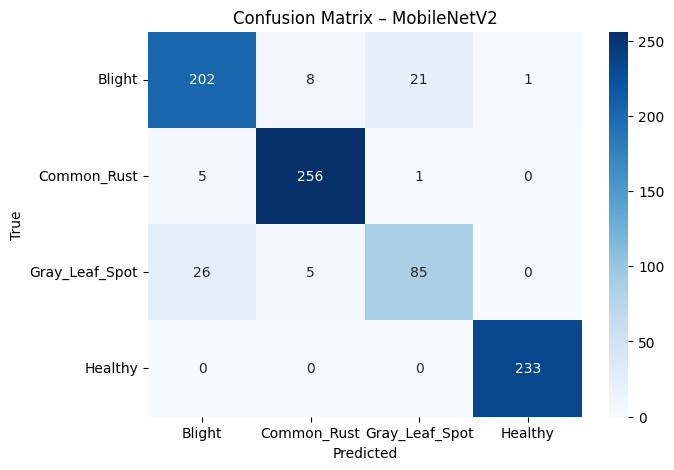

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(mobilenet_y_true, mobilenet_y_pred_classes)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – MobileNetV2")
plt.show()


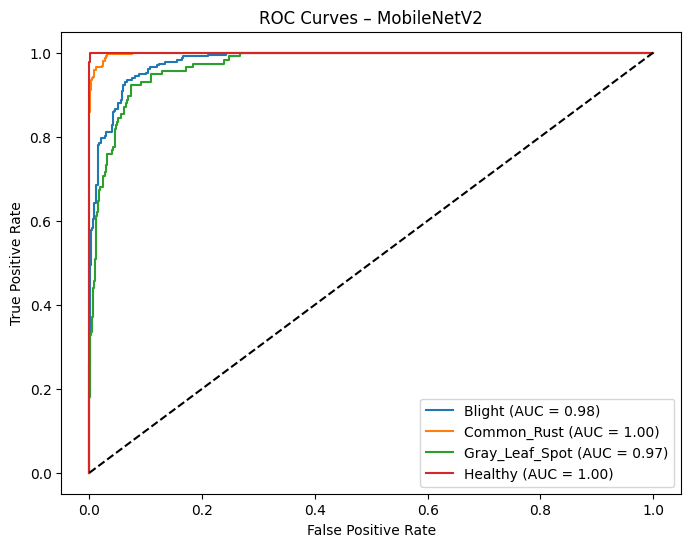

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

mobilenet_y_true_bin = label_binarize(mobilenet_y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(mobilenet_y_true_bin[:, i], mobilenet_y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – MobileNetV2")
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

resnet_base.trainable = False

inputs = layers.Input(shape=(img_size[0], img_size[1], 3))
x = resnet_base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

resnet_model = models.Model(inputs, outputs)

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks_resnet = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='resnet50_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
epochs = 30

history_resnet = resnet_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=callbacks_resnet
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.2662 - loss: 1.6156
Epoch 1: val_accuracy improved from -inf to 0.30935, saving model to resnet50_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 671ms/step - accuracy: 0.2665 - loss: 1.6143 - val_accuracy: 0.3094 - val_loss: 1.2984 - learning_rate: 0.0010
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.3374 - loss: 1.3573
Epoch 2: val_accuracy improved from 0.30935 to 0.48681, saving model to resnet50_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 535ms/step - accuracy: 0.3377 - loss: 1.3571 - val_accuracy: 0.4868 - val_loss: 1.2390 - learning_rate: 0.0010
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.3897 - loss: 1.2954
Epoch 3: val_accuracy improved from 0.48681 to 0.51559, saving model to resnet50_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 533ms/step - accuracy: 0.3898 - loss: 1.2953 - val_accuracy: 0.5156 - val_loss: 1.1951 - learning_rate: 0.0010
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4546 - loss: 1.2359
Epoch 4: val_accuracy did not improve from 0.51559
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 539ms/step - accuracy: 0.4548 - loss: 1.2359 - val_accuracy: 0.4964 - val_loss: 1.1731 - learning_rate: 0.0010
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.4751 - loss: 1.2149
Epoch 5: val_accuracy improved from 0.51559 to 0.54436, saving model to resnet50_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 542ms/step - accuracy: 0.4752 - loss: 1.2149 - val_accuracy: 0.5444 - val_loss: 1.1534 - learning_rate: 0.0010
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.5327 - loss: 1.1598
Epoch 6: val_accuracy improved from 0.54436 to 0.56595, saving model to resnet50_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 543ms/step - accuracy: 0.5326 - loss: 1.1599 - val_accuracy: 0.5659 - val_loss: 1.1169 - learning_rate: 0.0010
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.5111 - loss: 1.1725
Epoch 7: val_accuracy improved from 0.56595 to 0.63789, saving model to resnet50_best.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 536ms/step - accuracy: 0.5113 - loss: 1.1724 - val_accuracy: 0.6379 - val_loss: 1.1009 - learning_rate: 0.0010
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.5191 - loss: 1.1489
Epoch 8: val_accuracy did not improve from 0.63789
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 544ms/step - accuracy: 0.5191 - loss: 1.1489 - val_accuracy: 0.5588 - val_loss: 1.0852 - learning_rate: 0.0010
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.5374 - loss: 1.1167
Epoch 9: val_accuracy did not improve from 0.63789

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 543ms/step - accuracy: 0.5373 - loss: 1.1169 - val_accuracy: 0.5707 - val_loss: 1.0743 - learning_rate: 0.0010
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.5493 - loss: 1.1018
Epoch 10: val_accuracy did not improve from 0.63789
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 534ms/step - accuracy: 0.5493 - loss: 1.1019 - val_ac

In [ ]:
resnet_y_pred = resnet_model.predict(test_gen)
resnet_y_pred_classes = np.argmax(resnet_y_pred, axis=1)

resnet_y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("İlk 10 tahmin:", resnet_y_pred_classes[:10])
print("İlk 10 gerçek:", resnet_y_true[:10])


27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step
İlk 10 tahmin: [1 3 0 3 0 0 0 3 0 3]
İlk 10 gerçek: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print("ResNet - Classification Report:")
print(classification_report(
    resnet_y_true,
    resnet_y_pred_classes,
    target_names=class_labels,
    digits=4
))


ResNet - Classification Report:
                precision    recall  f1-score   support

        Blight     0.4881    0.5302    0.5083       232
   Common_Rust     0.8505    0.9122    0.8803       262
Gray_Leaf_Spot     0.6923    0.2328    0.3484       116
       Healthy     0.6015    0.6996    0.6468       233

      accuracy                         0.6548       843
     macro avg     0.6581    0.5937    0.5959       843
  weighted avg     0.6602    0.6548    0.6402       843



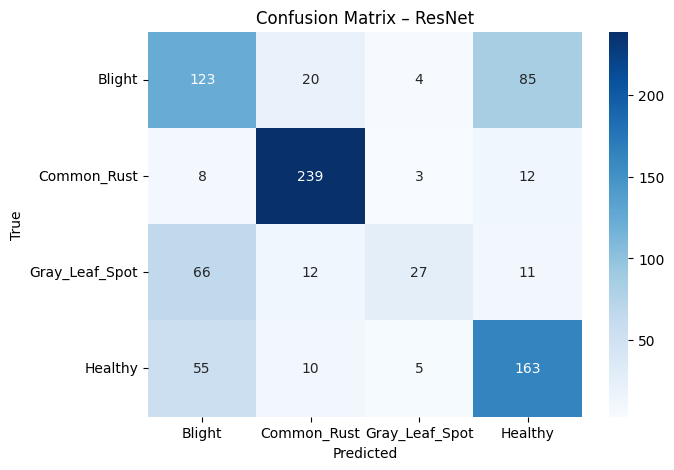

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(resnet_y_true, resnet_y_pred_classes)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – ResNet")
plt.show()


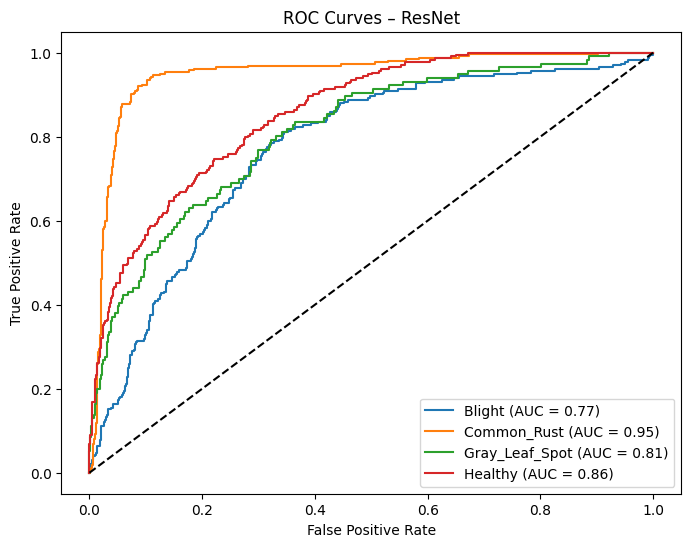

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

resnet_y_true_bin = label_binarize(resnet_y_true, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(resnet_y_true_bin[:, i], resnet_y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – ResNet")
plt.legend()
plt.show()

In [ ]:
# Model4-DenseNet121
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

img_size = (224, 224)

densenet_base = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

densenet_base.trainable = False

densenet_model = Sequential([
    densenet_base,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

densenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

densenet_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
import tensorflow as tf

callbacks_densenet = [
    tf.keras.callbacks.ModelCheckpoint(
        "densenet121_best.h5",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]


In [ ]:
epochs = 20

history_densenet = densenet_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=callbacks_densenet
)


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.4420 - loss: 1.3707

92/92 ━━━━━━━━━━━━━━━━━━━━ 112s 926ms/step - accuracy: 0.4434 - loss: 1.3672 - val_accuracy: 0.7914 - val_loss: 0.5418 - learning_rate: 1.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.7582 - loss: 0.6067

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 563ms/step - accuracy: 0.7585 - loss: 0.6063 - val_accuracy: 0.8465 - val_loss: 0.3927 - learning_rate: 1.0000e-04
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8127 - loss: 0.4790

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 561ms/step - accuracy: 0.8128 - loss: 0.4786 - val_accuracy: 0.8777 - val_loss: 0.3289 - learning_rate: 1.0000e-04
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.8365 - loss: 0.4040

92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 547ms/step - accuracy: 0.8365 - loss: 0.4040 - val_accuracy: 0.8945 - val_loss: 0.2978 - learning_rate: 1.0000e-04
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8377 - loss: 0.3874

92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 538ms/step - accuracy: 0.8379 - loss: 0.3872 - val_accuracy: 0.9089 - val_loss: 0.2661 - learning_rate: 1.0000e-04
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 542ms/step - accuracy: 0.8646 - loss: 0.3425 - val_accuracy: 0.9041 - val_loss: 0.2540 - learning_rate: 1.0000e-04
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.8685 - loss: 0.3297

92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 547ms/step - accuracy: 0.8685 - loss: 0.3297 - val_accuracy: 0.9113 - val_loss: 0.2389 - learning_rate: 1.0000e-04
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8838 - loss: 0.3117

92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 542ms/step - accuracy: 0.8838 - loss: 0.3117 - val_accuracy: 0.9209 - val_loss: 0.2255 - learning_rate: 1.0000e-04
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 533ms/step - accuracy: 0.8830 - loss: 0.3109 - val_accuracy: 0.9185 - val_loss: 0.2221 - learning_rate: 1.0000e-04
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8994 - loss: 0.2618

92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 549ms/step - accuracy: 0.8993 - loss: 0.2619 - val_accuracy: 0.9233 - val_loss: 0.2091 - learning_rate: 1.0000e-04
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 541ms/step - accuracy: 0.8817 - loss: 0.2908 - val_accuracy: 0.9161 - val_loss: 0.2027 - learning_rate: 1.0000e-04
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 533ms/step - accuracy: 0.8870 - loss: 0.2859 - val_accuracy: 0.9161 - val_loss: 0.2000 - learning_rate: 1.0000e-04
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 541ms/step - accuracy: 0.8938 - loss: 0.2711 - val_accuracy: 0.9185 - val_loss: 0.1947 - learning_rate: 1.0000e-04
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 541ms/step - accuracy: 0.8908 - loss: 0.2730 - val_accuracy: 0.9185 - val_loss: 0.2036 - learning_rate: 1.0000e-04
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.8926 - loss: 0.2588

92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 546ms/step - accuracy: 0.8926 - loss: 0.2587 - val_accuracy: 0.9329 - val_loss: 0.1930 - learning_rate: 1.0000e-04
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 533ms/step - accuracy: 0.9007 - loss: 0.2727 - val_accuracy: 0.9281 - val_loss: 0.1844 - learning_rate: 1.0000e-04
Epoch 17/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 540ms/step - accuracy: 0.9145 - loss: 0.2300 - val_accuracy: 0.9209 - val_loss: 0.1843 - learning_rate: 1.0000e-04
Epoch 18/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 542ms/step - accuracy: 0.9045 - loss: 0.2427 - val_accuracy: 0.9281 - val_loss: 0.1790 - learning_rate: 1.0000e-04
Epoch 19/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 532ms/step - accuracy: 0.9061 - loss: 0.2524 - val_accuracy: 0.9305 - val_loss: 0.1774 - learning_rate: 1.0000e-04
Epoch 20/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 537ms/step - accuracy: 0.9006 - loss: 0.2471 - val_accuracy: 0.9281 - val_loss: 0.1772 - learning_rate: 1.0000e-04


In [ ]:
import numpy as np

densenet_y_pred = densenet_model.predict(test_gen)
densenet_y_pred_classes = np.argmax(densenet_y_pred, axis=1)

densenet_y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("İlk 10 tahmin:", densenet_y_pred_classes[:10])
print("İlk 10 gerçek:", densenet_y_true[:10])


27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 773ms/step
İlk 10 tahmin: [0 0 0 0 0 0 0 0 0 0]
İlk 10 gerçek: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print("DenseNet121 - Classification Report:")
print(classification_report(
    densenet_y_true,
    densenet_y_pred_classes,
    target_names=class_labels,
    digits=4
))


DenseNet121 - Classification Report:
                precision    recall  f1-score   support

        Blight     0.8612    0.9095    0.8847       232
   Common_Rust     0.9763    0.9427    0.9592       262
Gray_Leaf_Spot     0.8393    0.8103    0.8246       116
       Healthy     0.9957    0.9957    0.9957       233

      accuracy                         0.9300       843
     macro avg     0.9181    0.9146    0.9160       843
  weighted avg     0.9311    0.9300    0.9303       843



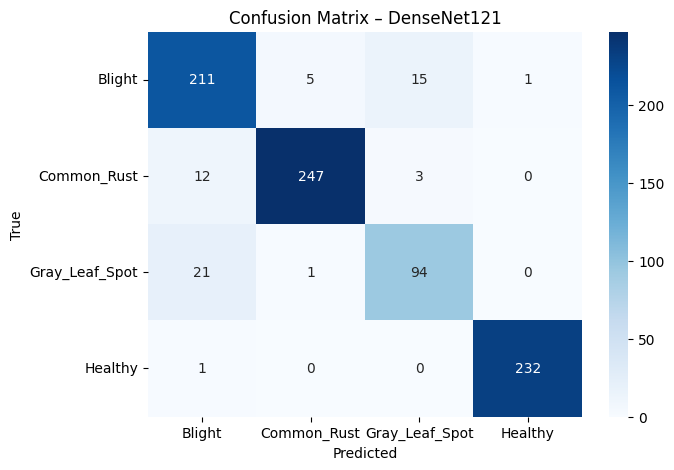

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(densenet_y_true, densenet_y_pred_classes)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – DenseNet121")
plt.show()


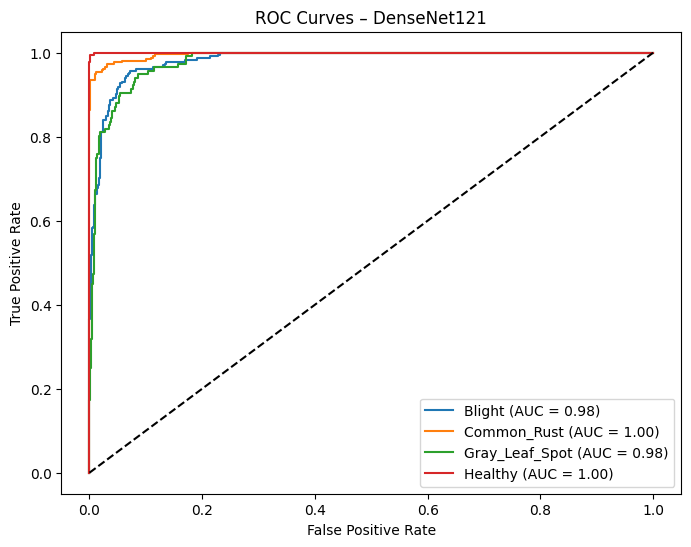

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

densenet_y_true_bin = label_binarize(densenet_y_true, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(densenet_y_true_bin[:, i], densenet_y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – DenseNet121")
plt.legend()
plt.show()


In [ ]:
# Model5-VGG16
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

img_size = (224, 224)

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

vgg_base.trainable = False

vgg_model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
import tensorflow as tf

callbacks_vgg = [
    tf.keras.callbacks.ModelCheckpoint(
        "vgg16_best.h5",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]


In [ ]:
epochs = 20

history_vgg = vgg_model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=callbacks_vgg
)


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.3270 - loss: 1.4046

92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 709ms/step - accuracy: 0.3281 - loss: 1.4033 - val_accuracy: 0.7050 - val_loss: 1.0719 - learning_rate: 1.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.5827 - loss: 1.0899

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 568ms/step - accuracy: 0.5830 - loss: 1.0894 - val_accuracy: 0.7554 - val_loss: 0.8885 - learning_rate: 1.0000e-04
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 564ms/step - accuracy: 0.6599 - loss: 0.9276 - val_accuracy: 0.7482 - val_loss: 0.7787 - learning_rate: 1.0000e-04
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.6954 - loss: 0.8295

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 560ms/step - accuracy: 0.6955 - loss: 0.8292 - val_accuracy: 0.7578 - val_loss: 0.6887 - learning_rate: 1.0000e-04
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.7206 - loss: 0.7392

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 559ms/step - accuracy: 0.7207 - loss: 0.7390 - val_accuracy: 0.7602 - val_loss: 0.6427 - learning_rate: 1.0000e-04
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7462 - loss: 0.6786

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 567ms/step - accuracy: 0.8024 - loss: 0.5332 - val_accuracy: 0.8201 - val_loss: 0.4786 - learning_rate: 1.0000e-04
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.8065 - loss: 0.5124

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 567ms/step - accuracy: 0.8065 - loss: 0.5125 - val_accuracy: 0.8225 - val_loss: 0.4654 - learning_rate: 1.0000e-04
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 561ms/step - accuracy: 0.8090 - loss: 0.5294 - val_accuracy: 0.8129 - val_loss: 0.4606 - learning_rate: 1.0000e-04
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 564ms/step - accuracy: 0.8200 - loss: 0.4842 - val_accuracy: 0.8177 - val_loss: 0.4549 - learning_rate: 1.0000e-04
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 562ms/step - accuracy: 0.8304 - loss: 0.4674 - val_accuracy: 0.8225 - val_loss: 0.4453 - learning_rate: 1.0000e-04
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.8301 - loss: 0.4715

92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 555ms/step - accuracy: 0.8301 - loss: 0.4716 - val_accuracy: 0.8249 - val_loss: 0.4363 - learning_rate: 1.0000e-04
Epoch 17/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.8310 - loss: 0.4734

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 559ms/step - accuracy: 0.8309 - loss: 0.4734 - val_accuracy: 0.8369 - val_loss: 0.4241 - learning_rate: 1.0000e-04
Epoch 18/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 558ms/step - accuracy: 0.8347 - loss: 0.4731 - val_accuracy: 0.8345 - val_loss: 0.4137 - learning_rate: 1.0000e-04
Epoch 19/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 565ms/step - accuracy: 0.8297 - loss: 0.4541 - val_accuracy: 0.8345 - val_loss: 0.4189 - learning_rate: 1.0000e-04
Epoch 20/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8312 - loss: 0.4513

92/92 ━━━━━━━━━━━━━━━━━━━━ 52s 560ms/step - accuracy: 0.8312 - loss: 0.4515 - val_accuracy: 0.8513 - val_loss: 0.3980 - learning_rate: 1.0000e-04


In [ ]:
import numpy as np

vgg_y_pred = vgg_model.predict(test_gen)
vgg_y_pred_classes = np.argmax(vgg_y_pred, axis=1)

vgg_y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("İlk 10 tahmin:", vgg_y_pred_classes[:10])
print("İlk 10 gerçek:", vgg_y_true[:10])


27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 409ms/step
İlk 10 tahmin: [1 0 0 0 0 0 0 0 0 0]
İlk 10 gerçek: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report

print("VGG16 - Classification Report:")
print(classification_report(
    vgg_y_true,
    vgg_y_pred_classes,
    target_names=class_labels,
    digits=4
))


VGG16 - Classification Report:
                precision    recall  f1-score   support

        Blight     0.7500    0.8534    0.7984       232
   Common_Rust     0.9098    0.9237    0.9167       262
Gray_Leaf_Spot     0.7600    0.4914    0.5969       116
       Healthy     0.9454    0.9657    0.9554       233

      accuracy                         0.8565       843
     macro avg     0.8413    0.8085    0.8168       843
  weighted avg     0.8550    0.8565    0.8508       843



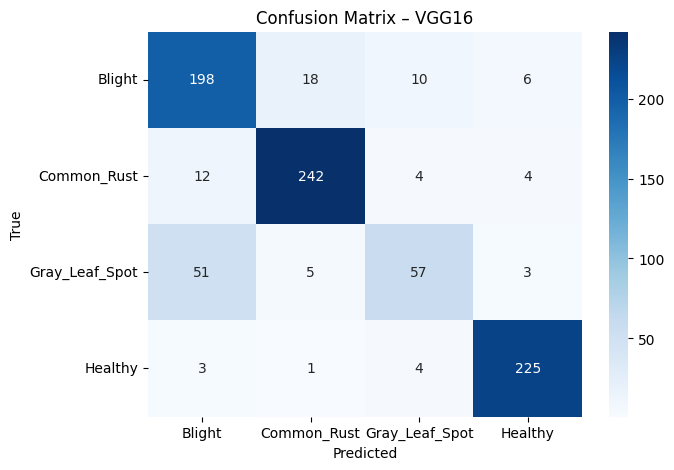

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(vgg_y_true, vgg_y_pred_classes)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – VGG16")
plt.show()


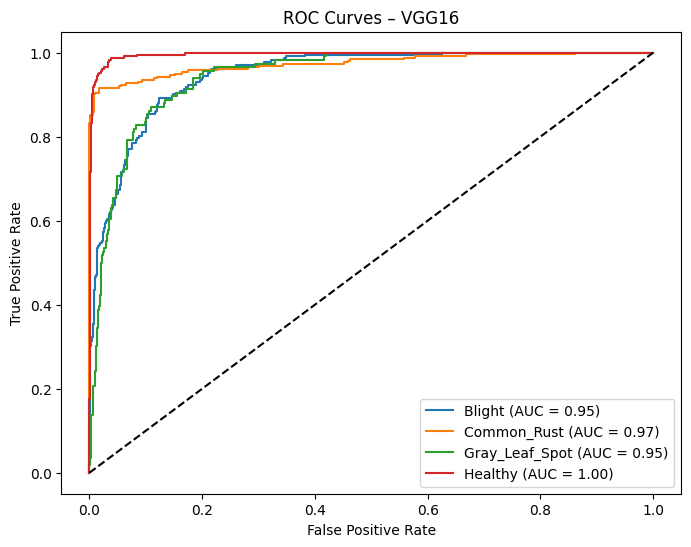

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

vgg_y_true_bin = label_binarize(vgg_y_true, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(vgg_y_true_bin[:, i], vgg_y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – VGG16")
plt.legend()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

base_path = "/content/drive/MyDrive/Colab Notebooks/"

model_files = [
    ("cnn_best.h5",          "Custom CNN"),
    ("densenet121_best.h5",  "DenseNet121"),
    ("mobilenetv2_best.h5",  "MobileNetV2"),
    ("resnet50_best.h5",     "ResNet50"),
    ("vgg16_best.h5",        "VGG16"),
]

loaded_models = []

for file_name, name in model_files:
    full_path = base_path + file_name
    print(f"\nYükleniyor: {full_path}")
    try:
        model = tf.keras.models.load_model(full_path, compile=False)
        loaded_models.append((model, name))
        print(f" Başarılı: {name}")
    except Exception as e:
        print(f" HATA: {name} yüklenemedi")
        print("Hata mesajı:", e)



Yükleniyor: /content/drive/MyDrive/Colab Notebooks/cnn_best.h5
 Başarılı: Custom CNN

Yükleniyor: /content/drive/MyDrive/Colab Notebooks/densenet121_best.h5
 Başarılı: DenseNet121

Yükleniyor: /content/drive/MyDrive/Colab Notebooks/mobilenetv2_best.h5
 Başarılı: MobileNetV2

Yükleniyor: /content/drive/MyDrive/Colab Notebooks/resnet50_best.h5
 Başarılı: ResNet50

Yükleniyor: /content/drive/MyDrive/Colab Notebooks/vgg16_best.h5
 Başarılı: VGG16


In [ ]:
from tensorflow.keras.optimizers import Adam

for i, (model, name) in enumerate(loaded_models):
    print("Compile ediliyor:", name)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
print("Tüm modeller compile edildi ")


Compile ediliyor: Custom CNN
Compile ediliyor: DenseNet121
Compile ediliyor: MobileNetV2
Compile ediliyor: ResNet50
Compile ediliyor: VGG16
Tüm modeller compile edildi 


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

class_names = list(test_gen.class_indices.keys())
num_classes = len(class_names)

results = []

for model, name in loaded_models:
    print("\nModel değerlendiriliyor:", name)
    test_gen.reset()

    loss, acc = model.evaluate(test_gen, verbose=0)

    y_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )
    macro_f1 = report["macro avg"]["f1-score"]

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Test_Loss": loss
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df



Model değerlendiriliyor: Custom CNN

Model değerlendiriliyor: DenseNet121

Model değerlendiriliyor: MobileNetV2

Model değerlendiriliyor: ResNet50

Model değerlendiriliyor: VGG16


,Model,Accuracy,Macro_F1,Test_Loss
1,DenseNet121,0.928826,0.914557,0.197729
2,MobileNetV2,0.913405,0.888154,0.199192
0,Custom CNN,0.893238,0.873022,0.262819
4,VGG16,0.823250,0.766794,0.460287
3,ResNet50,0.642942,0.555100,1.119892
